# ROS2 Light Curve Extraction

Extract multi-band optical light curves from rospipe photometry output files.

## How it works

1. Scans all `phot_*.txt` files inside the `reduced/` folder(s)
2. Parses every header field (OBJECT, DATE-OBS, EXPTIME, filter, catalog, zeropoint, RMS, quality, limiting magnitude, calibration star count)
3. Cross-matches the source list against your target coordinates within a configurable radius
4. Reads all source columns including instrumental/catalog magnitudes and quality flags
5. Classifies each epoch as **detection** or **upper limit** (limiting magnitude)
6. Outputs a time-sorted CSV and DataFrame ready for plotting

## Batch analysis — process many nights first

Before running this notebook in multi-night mode, reduce all nights with rospipe.
Run this from the parent folder containing one subfolder per night:

```bash
cd /path/to/all_nights

for dir in */; do
    echo "========== Processing: $dir =========="
    python rospipe.py "$dir" -o "$dir"/reduced
done
```

If you only want to re-run photometry on already-reduced files (skip bias/flat/CR):

```bash
cd /path/to/all_nights

for dir in */; do
    echo "========== Processing: $dir =========="
    python rospipe.py "$dir" --phot-only -o "$dir"/reduced
done
```

## Input modes

**Single night** — point `INPUT_FOLDER` directly to the pipeline output folder:

```python
INPUT_FOLDER = "/path/to/20260115/reduced"
RECURSIVE    = False
```

Expected structure:

```
reduced/
├── phot_red_OGLE-0204_g_001.txt
├── phot_red_OGLE-0204_r_001.txt
└── ...
```

**Multiple nights** — point `INPUT_FOLDER` to the parent and enable recursion:

```python
INPUT_FOLDER = "/path/to/all_nights"
RECURSIVE    = True
```

Expected structure:

```
all_nights/
├── 20260115/reduced/phot_*.txt
├── 20260116/reduced/phot_*.txt
└── ...
```

## Catalog columns

| Column | Index | Description |
|--------|-------|-------------|
| `id` | 0 | Source ID |
| `x_pix` | 1 | Pixel X position |
| `y_pix` | 2 | Pixel Y position |
| `ra_deg` | 3 | Right Ascension [deg] |
| `dec_deg` | 4 | Declination [deg] |
| `flux_adu` | 5 | Aperture flux [ADU] |
| `flux_err_adu` | 6 | Flux error [ADU] |
| `mag_inst` | 7 | Instrumental magnitude |
| `mag_inst_err` | 8 | Instrumental magnitude error |
| `mag_cal` | 9 | Calibrated magnitude (`mag_inst + ZP`) |
| `mag_cal_err` | 10 | Calibrated magnitude error |
| `flag` | 11 | Quality flag |
| `mag_cat` | 12 | Catalog magnitude (`-99` if unmatched) |
| `mag_cat_err` | 13 | Catalog magnitude error (`-99` if unmatched) |

## Quality flags

| Flag | Meaning |
|------|---------|
| 0 | isolated + central — best quality |
| 1 | crowded (neighbour within isolation radius) |
| 2 | border (outside central fraction of image) |
| 3 | crowded + border — worst quality |
| 4 | **forced photometry** — position injected, not blind-detected |

## Detection logic

```
Source found within TOLERANCE_ARCSEC?
├── YES, flag=4 (forced) ── e_mag_cal ≤ MAX_MAG_ERROR? ── YES → FORCED DETECTION  (diamond ◇)
│                                                        └── NO  → upper limit
├── YES, flag≠4 (blind) ─── e_mag_cal ≤ MAX_MAG_ERROR? ── YES → DETECTION  (circle ●)

│                                                        └── NO  → upper limitThe notebook promotes it to a forced detection or demotes it to upper limit based on `MAX_MAG_ERROR`.

└── NO ──────────────────────────────────────────────────────── upper limit (Limiting_mag)**Forced photometry is always saved by rospipe** as long as flux > 0.

```

In [15]:
"""
Extract a light curve from rospipe photometry files.

Searches phot_*.txt in reduced/ folders, cross-matches each source list
against a target position, and returns a time-sorted DataFrame.
"""

import os
import glob

import numpy as np
import pandas as pd
from astropy.time import Time
import matplotlib.pyplot as plt


# =============================================================================
# Configuration — edit these for your target
# =============================================================================

INPUT_FOLDER     = "path/to/your/folder"    # single night: the reduced/ dir
                                            # multi-night:  the parent dir
RECURSIVE        = True                     # False = single folder
                                            # True  = recurse into subfolders

TARGET_RA        = 209.5405                 # target Right Ascension  [deg]
TARGET_DEC       = -64.7348                 # target Declination      [deg]
TOLERANCE_ARCSEC = 3.0                      # cross-match radius      [arcsec]
MAX_MAG_ERROR    = 0.4                      # detections with err > this → upper limit

OUTPUT_CSV       = "lightcurve_ros2.csv"

# Filter by OBJECT keyword.
#   TARGET_OBJECTS = ["GX_339-4"]           -> keep only this object
#   TARGET_OBJECTS = ["SN2026acd", "M31"]   -> keep two objects
#   TARGET_OBJECTS = None                   -> accept everything
TARGET_OBJECTS   = None

# Filter by band.
#   FILTERS_KEEP = ["g", "r"]              -> g and r only
#   FILTERS_KEEP = None                    -> all bands
FILTERS_KEEP     = None

In [16]:
# =============================================================================
# Parser
# =============================================================================

def parse_phot_file(filepath, target_ra, target_dec,
                    tolerance_arcsec, max_mag_error=0.33,
                    target_objects=None, filters_keep=None):
    """Parse one phot_*.txt and return a record dict, or None if skipped.

    mag_cal / mag_cal_err contain the measured source magnitude (or 99/99
    if no source found within the tolerance radius).
    Limiting_mag is always read from the header independently.
    is_detection = True when source found AND mag_cal_err <= max_mag_error.
    """
    rec = dict(
        filename=os.path.basename(filepath),
        # header fields
        OBJECT=None, DATE_OBS=None, EXPTIME=None, Filter=None,
        Catalog=None,
        Zeropoint=None, ZP_err=None, RMS=None, Quality=None,
        Limiting_mag=None, N_cal_used=None, N_cal_total=None,
        Aperture_pix=None, Aperture_arcsec=None,
        # source match fields
        x=None, y=None,
        mag_inst=99.0,  mag_inst_err=99.0,
        mag_cat=-99.0,  mag_cat_err=-99.0,
        mag_cal=99.0,   mag_cal_err=99.0,
        flag=None, is_crowded=False, is_border=False,
        is_detection=False, separation_arcsec=None,
    )

    try:
        with open(filepath) as fh:
            lines = fh.readlines()
    except OSError:
        return None

    # -- header metadata ---------------------------------------------------
    for line in lines:
        if not line.startswith("#"):
            break
        if "Object:" in line:
            rec["OBJECT"] = line.split("Object:")[1].strip()
        elif "Filter:" in line:
            rec["Filter"] = line.split("Filter:")[1].strip()
        elif "Date-obs:" in line:
            rec["DATE_OBS"] = line.split("Date-obs:")[1].strip()
        elif "Exptime:" in line:
            try:
                rec["EXPTIME"] = float(
                    line.split("Exptime:")[1].replace("s", "").strip())
            except ValueError:
                pass
        elif "Catalog:" in line:
            rec["Catalog"] = line.split("Catalog:")[1].strip()
        elif "Zeropoint:" in line and "+/-" in line:
            try:
                zp, ze = line.split("Zeropoint:")[1].strip().split("+/-")
                rec["Zeropoint"] = float(zp.strip())
                rec["ZP_err"]    = float(ze.replace("mag", "").strip())
            except (ValueError, IndexError):
                pass
        elif "RMS:" in line:
            try:
                rec["RMS"] = float(
                    line.split("RMS:")[1].replace("mag", "").strip())
            except ValueError:
                pass
        elif "Quality:" in line:
            rec["Quality"] = line.split("Quality:")[1].strip()
        elif "Lim_mag" in line:
            try:
                rec["Limiting_mag"] = float(
                    line.split(":")[1].replace("mag", "").strip())
            except ValueError:
                pass
        elif "N_cal:" in line:
            try:
                parts = line.split("N_cal:")[1].strip().split("/")
                rec["N_cal_used"]  = int(parts[0].strip())
                rec["N_cal_total"] = int(parts[1].strip())
            except (ValueError, IndexError):
                pass
        elif "Aperture:" in line:
            try:
                ap = line.split("Aperture:")[1].strip()
                rec["Aperture_pix"]    = float(ap.split("pix")[0].strip())
                rec["Aperture_arcsec"] = float(
                    ap.split("(")[1].split("arcsec")[0].strip())
            except (ValueError, IndexError):
                pass

    # -- OBJECT filter (early exit) ----------------------------------------
    if target_objects and rec["OBJECT"] not in target_objects:
        return None

    # -- band filter (early exit) ------------------------------------------
    if filters_keep and rec["Filter"] not in filters_keep:
        return None

    # -- DATE-OBS required -------------------------------------------------
    if not rec["DATE_OBS"]:
        return None

    # -- find closest source within tolerance ------------------------------
    cos_dec  = np.cos(np.radians(target_dec))
    best_sep = np.inf

    for line in lines:
        if line.startswith("#") or not line.strip():
            continue
        cols = line.strip().split()
        if len(cols) < 14:
            continue
        try:
            # id x y ra dec flux flux_err mag_inst mag_inst_err mag_cal mag_cal_err flag mag_cat mag_cat_err
            ra  = float(cols[3])
            dec = float(cols[4])
            sep = np.hypot((ra - target_ra) * cos_dec * 3600,
                           (dec - target_dec) * 3600)
            if sep < tolerance_arcsec and sep < best_sep:
                best_sep                 = sep
                rec["x"]                 = float(cols[1])
                rec["y"]                 = float(cols[2])
                rec["mag_inst"]          = float(cols[7])
                rec["mag_inst_err"]      = float(cols[8])
                rec["mag_cal"]           = float(cols[9])
                rec["mag_cal_err"]       = float(cols[10])
                rec["flag"]              = int(cols[11])
                rec["mag_cat"]           = float(cols[12])
                rec["mag_cat_err"]       = float(cols[13])
                rec["is_crowded"]        = rec["flag"] in (1, 3)
                rec["is_border"]         = rec["flag"] in (2, 3)
                rec["is_detection"]      = True
                rec["separation_arcsec"] = sep
        except (ValueError, IndexError):
            continue

    # -- demote noisy detections to upper limit ----------------------------
    if rec["is_detection"] and rec["mag_cal_err"] > max_mag_error:
        rec["is_detection"] = False

    return rec

In [17]:
# =============================================================================
# Collect photometry files
# =============================================================================

if RECURSIVE:
    pattern    = os.path.join(INPUT_FOLDER, "**", "reduced", "phot_*.txt")
    phot_files = sorted(glob.glob(pattern, recursive=True))
else:
    # INPUT_FOLDER can be the reduced/ dir itself OR its parent
    if os.path.basename(INPUT_FOLDER) == "reduced":
        pattern = os.path.join(INPUT_FOLDER, "phot_*.txt")
    else:
        pattern = os.path.join(INPUT_FOLDER, "reduced", "phot_*.txt")
    phot_files = sorted(glob.glob(pattern))

print(f"Target : RA = {TARGET_RA:.6f} deg   DEC = {TARGET_DEC:.6f} deg   "
      f"tolerance = {TOLERANCE_ARCSEC} arcsec")
print(f"Mode   : {'recursive' if RECURSIVE else 'single folder'}")
if TARGET_OBJECTS:
    print(f"OBJECT filter  : {TARGET_OBJECTS}")
if FILTERS_KEEP:
    print(f"Band filter    : {FILTERS_KEEP}")
print(f"Found {len(phot_files)} photometry file(s)\n")

Target : RA = 209.540500 deg   DEC = -64.734800 deg   tolerance = 6.0 arcsec
Mode   : recursive
Found 600 photometry file(s)



In [18]:
# =============================================================================
# Parse and cross-match
# =============================================================================

rows = []
for fp in phot_files:
    rec = parse_phot_file(fp, TARGET_RA, TARGET_DEC,
                          TOLERANCE_ARCSEC, MAX_MAG_ERROR,
                          TARGET_OBJECTS, FILTERS_KEEP)
    if rec is not None:
        rows.append(rec)

df = pd.DataFrame(rows)

# -- time columns ----------------------------------------------------------
df["datetime"]  = pd.to_datetime(df["DATE_OBS"], errors="coerce")
df["MJD"]       = df["DATE_OBS"].apply(
    lambda x: Time(x, format="isot").mjd if isinstance(x, str) and x else np.nan)
df["MJD_rel"]   = df["MJD"] - df["MJD"].min()
df["hours_rel"] = df["MJD_rel"] * 24.0

df = df.sort_values("MJD").reset_index(drop=True)
df.to_csv(OUTPUT_CSV, index=False)

# -- summary ---------------------------------------------------------------
n_det = int(df["is_detection"].sum())
n_ul  = len(df) - n_det
n_ul_lim = df[~df["is_detection"] & df["Limiting_mag"].notna()].shape[0]

print(f"Parsed           : {len(df)} epoch(s)")
print(f"Detections       : {n_det}")
print(f"Upper limits     : {n_ul}  ({n_ul_lim} with Limiting_mag)")
print(f"Objects          : {sorted(df['OBJECT'].dropna().unique())}")
print(f"Filters          : {sorted(df['Filter'].dropna().unique())}")
if not df['MJD'].isna().all():
    print(f"Time span        : MJD {df['MJD'].min():.4f} -- {df['MJD'].max():.4f}  "
          f"({df['MJD_rel'].max():.2f} days)")
print(f"Saved to         : {OUTPUT_CSV}\n")

# flags summary
det = df[df["is_detection"]]
if len(det) > 0 and det["flag"].notna().any():
    print("Detection quality flags:")
    print(f"  Isolated+central (flag=0) : {(det['flag']==0).sum()}")
    print(f"  Crowded          (flag=1) : {(det['flag']==1).sum()}")
    print(f"  Border           (flag=2) : {(det['flag']==2).sum()}")
    print(f"  Crowded+border   (flag=3) : {(det['flag']==3).sum()}\n")

display(df[["datetime", "MJD", "MJD_rel", "OBJECT", "Filter", "EXPTIME",
            "Catalog", "Zeropoint", "ZP_err", "RMS", "Quality",
            "mag_cal", "mag_cal_err", "Limiting_mag",
            "is_detection", "flag", "is_crowded", "is_border",
            "N_cal_used", "N_cal_total"]])

Parsed           : 600 epoch(s)
Detections       : 269
Upper limits     : 331  (314 with Limiting_mag)
Objects          : ['GS1354_645']
Filters          : ['g', 'i', 'r', 'z']
Time span        : MJD 61055.3278 -- 61131.2928  (75.96 days)
Saved to         : lightcurve_ros2.csv

Detection quality flags:
  Isolated+central (flag=0) : 269
  Crowded          (flag=1) : 0
  Border           (flag=2) : 0
  Crowded+border   (flag=3) : 0



,datetime,MJD,MJD_rel,OBJECT,Filter,EXPTIME,Catalog,Zeropoint,ZP_err,RMS,Quality,mag_cal,mag_cal_err,Limiting_mag,is_detection,flag,is_crowded,is_border,N_cal_used,N_cal_total
0,2026-01-15 07:52:05,61055.327836,0.000000,GS1354_645,z,30.0,skymapperdr4,-2.0994,0.0022,0.1370,GOOD,99.0,99.0,16.9922,False,NaN,False,False,334,365
1,2026-01-15 07:52:05,61055.327836,0.000000,GS1354_645,g,30.0,apass9,0.2558,0.0057,0.1470,GOOD,99.0,99.0,19.3950,False,NaN,False,False,22,22
2,2026-01-15 07:52:05,61055.327836,0.000000,GS1354_645,r,30.0,apass9,0.4475,0.0030,0.1294,GOOD,99.0,99.0,19.1573,False,NaN,False,False,19,20
3,2026-01-15 07:52:05,61055.327836,0.000000,GS1354_645,i,30.0,apass9,-0.4135,0.0090,0.1150,GOOD,99.0,99.0,18.2496,False,NaN,False,False,17,17
4,2026-01-15 07:54:52,61055.329769,0.001933,GS1354_645,i,30.0,apass9,-0.3784,0.0064,0.0712,VERY GOOD,99.0,99.0,18.2932,False,NaN,False,False,17,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,2026-04-01 06:58:56,61131.290926,75.963090,GS1354_645,i,30.0,apass9,-0.3091,0.0175,0.0858,VERY GOOD,99.0,99.0,17.9666,False,NaN,False,False,17,17
596,2026-04-01 07:01:40,61131.292824,75.964988,GS1354_645,z,30.0,skymapperdr4,-1.9789,0.0018,0.1046,GOOD,99.0,99.0,16.9683,False,NaN,False,False,428,468
597,2026-04-01 07:01:40,61131.292824,75.964988,GS1354_645,r,30.0,apass9,0.6216,0.0038,0.0615,VERY GOOD,99.0,99.0,18.5556,False,NaN,False,False,14,14
598,2026-04-01 07:01:40,61131.292824,75.964988,GS1354_645,i,30.0,apass9,-0.3324,0.0183,0.1009,GOOD,99.0,99.0,17.9418,False,NaN,False,False,16,16


## Diagnostics — Verifica del source matching

Controlla che stiamo sempre prendendo la stessa stella e che la separazione sia stabile nel tempo.

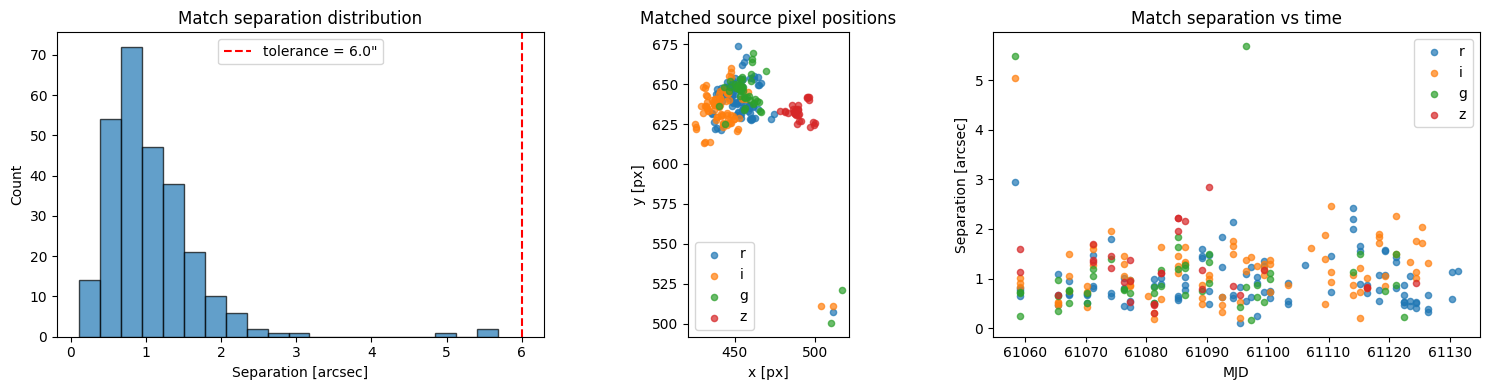

Separation stats (detections only):
  Mean:   1.06 arcsec
  Median: 0.91 arcsec
  Max:    5.68 arcsec
  Std:    0.68 arcsec


In [19]:
"""
Diagnostic 1: distribuzione delle separazioni.
Se le separazioni sono molto sparse il match è inaffidabile.
"""

det = df[df["is_detection"]].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1a) separazione — istogramma
ax = axes[0]
ax.hist(det["separation_arcsec"].dropna(), bins=20, edgecolor="k", alpha=0.7)
ax.axvline(TOLERANCE_ARCSEC, color="r", ls="--",
           label=f"tolerance = {TOLERANCE_ARCSEC}\"")
ax.set_xlabel("Separation [arcsec]")
ax.set_ylabel("Count")
ax.set_title("Match separation distribution")
ax.legend()

# 1b) posizioni pixel — devono clusterizzare
ax = axes[1]
for f in det["Filter"].dropna().unique():
    mask = det["Filter"] == f
    ax.scatter(det.loc[mask, "x"], det.loc[mask, "y"],
               label=f, s=20, alpha=0.7)
ax.set_xlabel("x [px]")
ax.set_ylabel("y [px]")
ax.set_title("Matched source pixel positions")
ax.legend()
ax.set_aspect("equal")

# 1c) separazione nel tempo — deriva indica problemi WCS
ax = axes[2]
for f in det["Filter"].dropna().unique():
    mask = det["Filter"] == f
    ax.scatter(det.loc[mask, "MJD"], det.loc[mask, "separation_arcsec"],
               label=f, s=20, alpha=0.7)
ax.set_xlabel("MJD")
ax.set_ylabel("Separation [arcsec]")
ax.set_title("Match separation vs time")
ax.legend()

plt.tight_layout()
plt.show()

print("Separation stats (detections only):")
print(f"  Mean:   {det['separation_arcsec'].mean():.2f} arcsec")
print(f"  Median: {det['separation_arcsec'].median():.2f} arcsec")
print(f"  Max:    {det['separation_arcsec'].max():.2f} arcsec")
print(f"  Std:    {det['separation_arcsec'].std():.2f} arcsec")

In [20]:
"""
Diagnostic 2: sorgenti multiple entro la tolerance.
Se ci sono più sorgenti nella stessa apertura il match può saltare tra stelle.
"""

def count_sources_near(filepath, target_ra, target_dec, tolerance_arcsec):
    cos_dec = np.cos(np.radians(target_dec))
    found = []
    try:
        with open(filepath) as fh:
            for line in fh:
                if line.startswith("#") or not line.strip():
                    continue
                cols = line.strip().split()
                if len(cols) < 14:
                    continue
                try:
                    ra, dec = float(cols[3]), float(cols[4])
                    sep = np.hypot((ra - target_ra) * cos_dec * 3600,
                                   (dec - target_dec) * 3600)
                    if sep <= tolerance_arcsec:
                        found.append({"ra": ra, "dec": dec,
                                      "mag_cal": float(cols[9]),
                                      "sep": sep})
                except (ValueError, IndexError):
                    continue
    except OSError:
        pass
    return found

sample = phot_files[:min(50, len(phot_files))]
multi  = []
for fp in sample:
    srcs = count_sources_near(fp, TARGET_RA, TARGET_DEC, TOLERANCE_ARCSEC)
    if len(srcs) > 1:
        multi.append({
            "file": os.path.basename(fp),
            "n_sources": len(srcs),
            "seps_arcsec": [f"{s['sep']:.2f}" for s in srcs],
            "mags": [f"{s['mag_cal']:.2f}" for s in srcs],
        })

if multi:
    print(f"WARNING: {len(multi)}/{len(sample)} file hanno PIU' sorgenti "
          f"entro {TOLERANCE_ARCSEC}\" — considera di ridurre TOLERANCE_ARCSEC.\n")
    for m in multi[:10]:
        print(f"  {m['file']}")
        print(f"    {m['n_sources']} sorgenti: sep = {m['seps_arcsec']}, "
              f"mag = {m['mags']}")
else:
    print(f"OK: tutti i {len(sample)} file controllati hanno al massimo "
          f"1 sorgente entro {TOLERANCE_ARCSEC}\" — match non ambiguo.")

OK: tutti i 50 file controllati hanno al massimo 1 sorgente entro 6.0" — match non ambiguo.


## Light curve plot

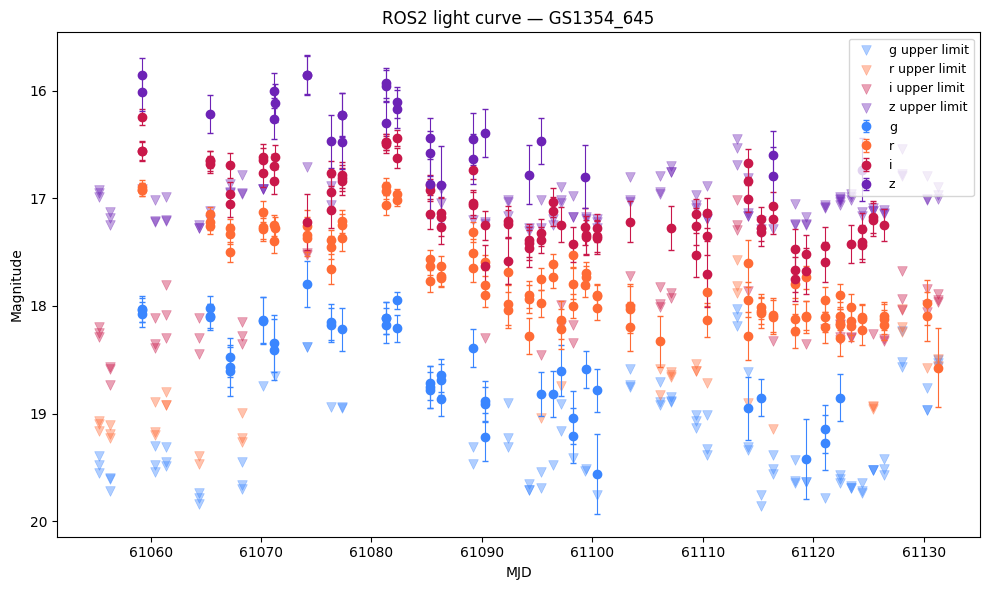

In [21]:
# =============================================================================
# Light curve: detections + upper limits per band
# =============================================================================
# Ricarica da CSV se necessario:
# df = pd.read_csv("lightcurve_ros2.csv")

BANDS   = ["g", "r", "i", "z"]
COLORS  = {"g": "#3a86ff", "r": "#ff6b35", "i": "#c9184a", "z": "#6d23b6"}
OFFSETS = {"g": 0.0, "r": 0.0, "i": 0.0, "z": 0.0}   # offset mag per chiarezza
SIZE    = 6

OBJECT_TITLE = df["OBJECT"].dropna().unique()[0] if len(df) > 0 else ""

fig, ax = plt.subplots(figsize=(10, 6))

for band in BANDS:
    c   = COLORS[band]
    off = OFFSETS[band]
    suf = f" ({band:+.1f})" if off != 0 else ""

    # Detections
    det = df[(df["Filter"] == band) & df["is_detection"] & (df["mag_cal"] < 90)]
    if len(det) > 0:
        ax.errorbar(det["MJD"], det["mag_cal"] + off, yerr=det["mag_cal_err"],
                    fmt="o", color=c, markersize=SIZE, capsize=2,
                    elinewidth=0.8, label=f"{band}{suf}", zorder=3)

    # Upper limits
    ul = df[(df["Filter"] == band) & ~df["is_detection"]
            & df["Limiting_mag"].notna() & (df["Limiting_mag"] < 90)]
    if len(ul) > 0:
        ax.scatter(ul["MJD"], ul["Limiting_mag"] + off,
                   marker="v", color=c, s=SIZE * 8, alpha=0.4,
                   edgecolors=c, linewidths=0.5,
                   label=f"{band} upper limit", zorder=2)

ax.invert_yaxis()
ax.set_xlabel("MJD")
ax.set_ylabel("Magnitude")
ax.legend(loc="best", fontsize=9)
ax.set_title(f"ROS2 light curve — {OBJECT_TITLE}")
plt.tight_layout()
plt.show()